In [1]:
import numpy as np
import imputation_utils
imputation_utils.CACHE_BASE_PATH = "../data/imputation_cache/5yr/"
from imputation_utils import char_groupings, char_maps, char_map
data = np.load('../data/raw_rank_trunk_chars_5yr.npz')
percentile_rank_chars = data['rank_chars']
regular_chars = data['raw_chars']
chars = data['chars']
dates = data['dates']
return_panel = data['returns']
permnos = data['permnos']
rts = data['rfs']
monthly_updates = data['monthly_updates']
from plots_and_tables import section_6

# section 6

## Figure 13: Market Premium Conditional on Observing a Firm Characteristic

This figure depicts the average annual return of stocks with observed or missing not-at-the-beginning (that is missing in middle or end of a stock sample) characteristics. The portfolios are value-weighted.

CPU times: user 2.46 s, sys: 3.12 s, total: 5.58 s
Wall time: 12.1 s

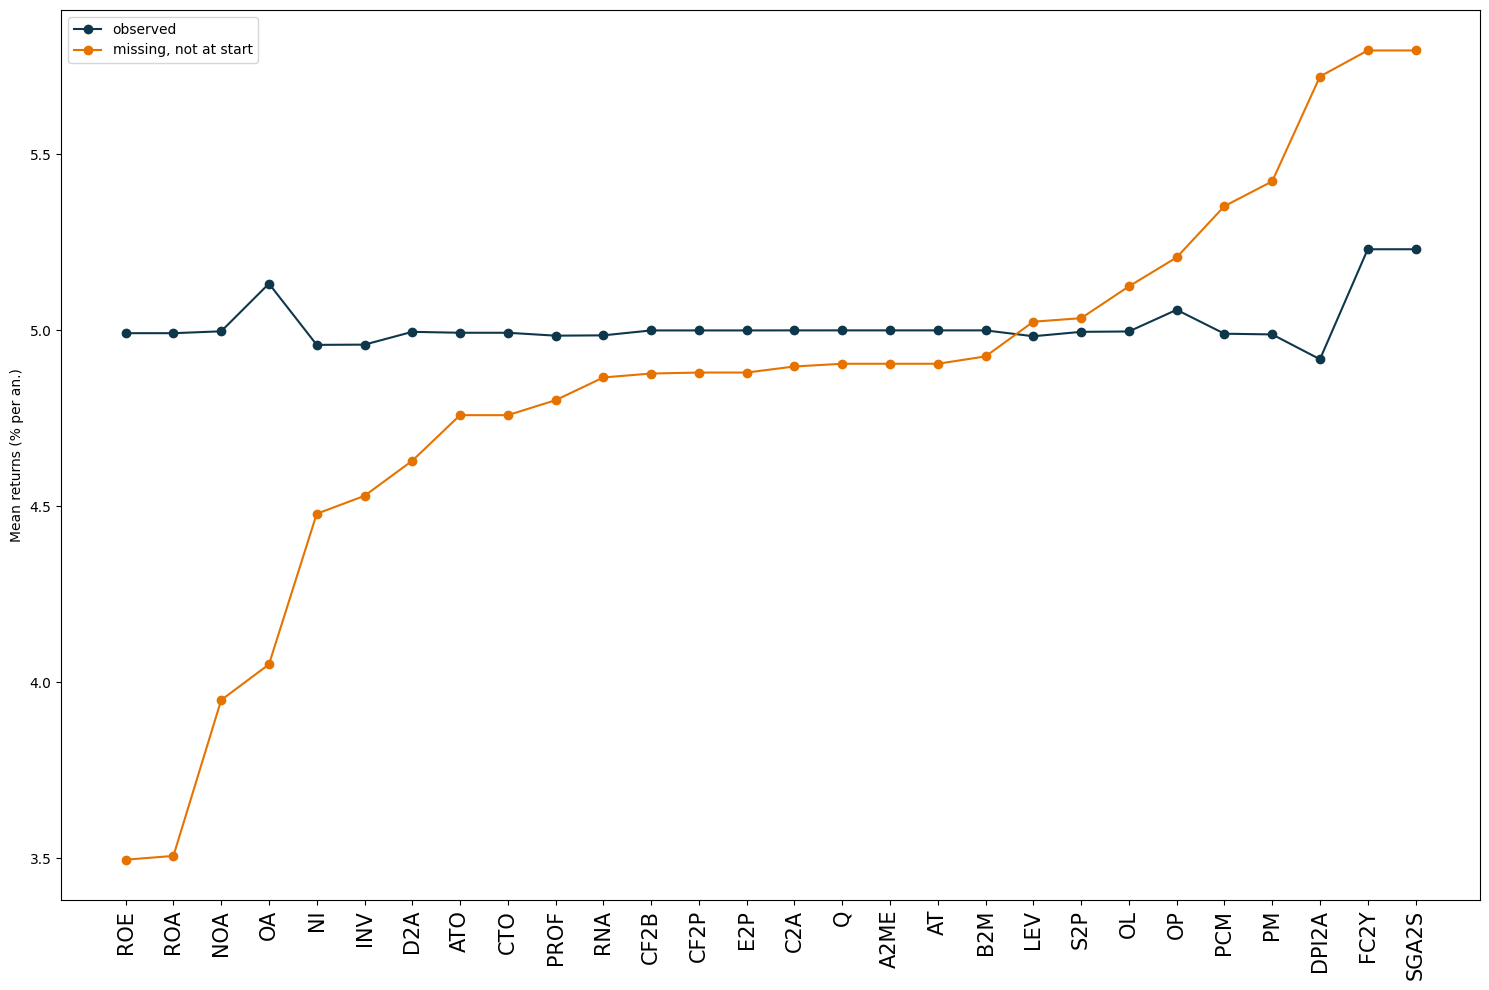

CPU times: user 399 ms, sys: 109 ms, total: 508 ms
Wall time: 512 ms


In [8]:
%%time

port_tgt_chars = [
    "A2ME", "AT", "ATO", "B2M", "C2A", "CF2B", "CF2P", "CTO", "D2A",
    "DPI2A", "E2P", "FC2Y", "INV", "LEV", "NI", "NOA", "OA", "OL",
    "OP", "PCM", "PM", "PROF", "Q", "RNA", "ROA", "ROE", "S2P", "SGA2S",
]

port_returns = [[] for _ in chars]
port_counts = [[] for _ in chars]
size_ind = np.argwhere(chars == "ME")[0][0]
start = 45
prev_obs_mask = np.any(~np.isnan(percentile_rank_chars[:start]), axis=0)
for t in range(start, percentile_rank_chars.shape[0] - 6):
    cut = np.nanquantile(regular_chars[t,:,size_ind], q=.95)
    cut = np.nanmax(regular_chars[t,:,size_ind])
    sizes = np.nan_to_num(regular_chars[t,:,size_ind])
    sizes[sizes > cut] = cut
    for i, c in enumerate(chars):
        if c in port_tgt_chars:
            p1 = np.logical_and(~np.isnan(percentile_rank_chars[t,:,i]) , ~np.isnan(regular_chars[t,:,size_ind]))
            p1 = np.logical_and(p1, ~np.isnan(return_panel[t+6]))
            p1_count = np.sum(p1)
            p1 = p1 * sizes
            p1 = p1 / np.sum(p1)

            p2 = np.logical_and(np.isnan(percentile_rank_chars[t,:,i]), prev_obs_mask[:,i])
            p2 = np.logical_and(p2, ~np.isnan(return_panel[t+6]))
            p2 = np.logical_and(p2, ~np.isnan(regular_chars[t,:,size_ind]))
            p2_count = np.sum(p2)
            p2 = p2 * sizes
            p2 = p2 / np.sum(p2)

            p1_ret = p1 @ np.nan_to_num(return_panel[t+6])
            p2_ret = p2 @ np.nan_to_num(return_panel[t+6])

            port_returns[i].append([p1_ret, p2_ret])
            port_counts[i].append(p2_count)
        else:
            port_returns[i].append([p1_ret, np.nan])
    prev_obs_mask = np.logical_or(prev_obs_mask, ~np.isnan(percentile_rank_chars[t]))

mean_returns = np.mean(port_returns, axis=1)
mycolors = ["#152eff", "#e67300", "#0e374c", "#6d904f", "#8b8b8b", "#30a2da", "#e5ae38", "#fc4f30",
            "#6d904f", "#8b8b8b", "#0e374c"]

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15,10))
ordering = np.argsort(mean_returns[:,1])
_ = plt.plot(np.arange(len(port_tgt_chars)), 100*mean_returns[:,0][ordering][:len(port_tgt_chars)],
             label="observed", c=mycolors[2], marker="o")
_ = plt.plot(np.arange(len(port_tgt_chars)), 100*mean_returns[:,1][ordering][:len(port_tgt_chars)],
             label="missing, not at start", c=mycolors[1], marker="o")
_ = plt.legend()
_ = plt.xticks(np.arange(len(port_tgt_chars)), chars[ordering][:len(port_tgt_chars)], rotation=90, fontsize=15)
_ = plt.ylabel("Mean returns (% per an.)")
plt.savefig(f"../images-pdfs/section6/ls-missing-obs-ports.pdf", bbox_inches="tight")
plt.show()


## Figure 14: Sharpe Ratios with IPCA Factors
This figure shows the in- and out-of-sample Sharpe ratios of mean-variance efficient combination for different numbers of IPCA factors. We estimate a conditional latent factor model with the Instrumented Principal Component Analysis of Kelly et al. (2019). The estimation is either on the small subset of fully observed or the large set of all imputed stocks. The in-sample analysis is estimated on the full time period, while the out-of-sample analysis estimates the loadings and mean-variance efficient weights on the first half of the time-series and evaluates the portfolios on the second half.

CPU times: user 5min 53s, sys: 2min 28s, total: 8min 21s
Wall time: 10min 58s

fitting on the train data
1e-10
the maxiter are 10000
10000
l-1
The panel dimensions are: 
n_samples: 1357 , L: 45 , T: 30


stop 86 - Aggregate Update: 9.214594365314355e-11 - my itertol is: 1e-10 - my maxiter is: 10000
l-2
fit the train data, fittings the out of sample data


100%|██████████| 24/24 [00:00<00:00, 6084.95it/s]

fitting on the train data
1e-10
the maxiter are 100000
100000
l-1


The panel dimensions are: 
n_samples: 4676 , L: 45 , T: 30


...

stop 197 - Aggregate Update: 9.417780791332042e-11 - my itertol is: 1e-10 - my maxiter is: 10000
l-2
fit the train data, fittings the out of sample data


100%|██████████| 24/24 [00:00<00:00, 2782.68it/s]


fitting on the train data
1e-10
the maxiter are 100000
100000
l-1
The panel dimensions are: 
n_samples: 4676 , L: 45 , T: 30


stop 129 - Aggregate Update: 9.951958701570618e-11 - my itertol is: 1e-10 - my maxiter is: 100000
l-2
fit the train data, fittings the out of sample data


100%|██████████| 24/24 [00:00<00:00, 1277.76it/s]


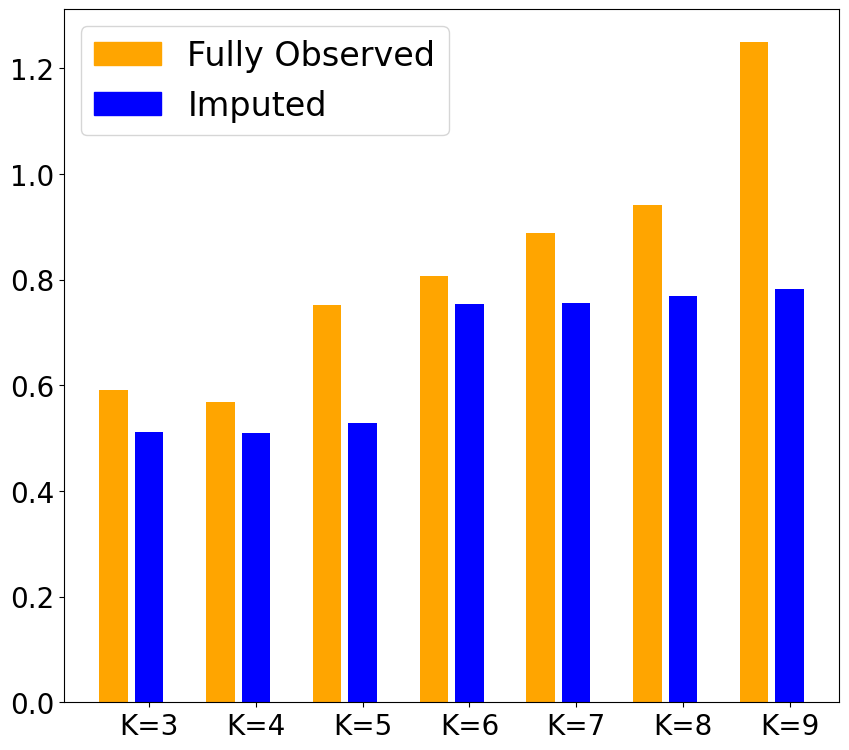

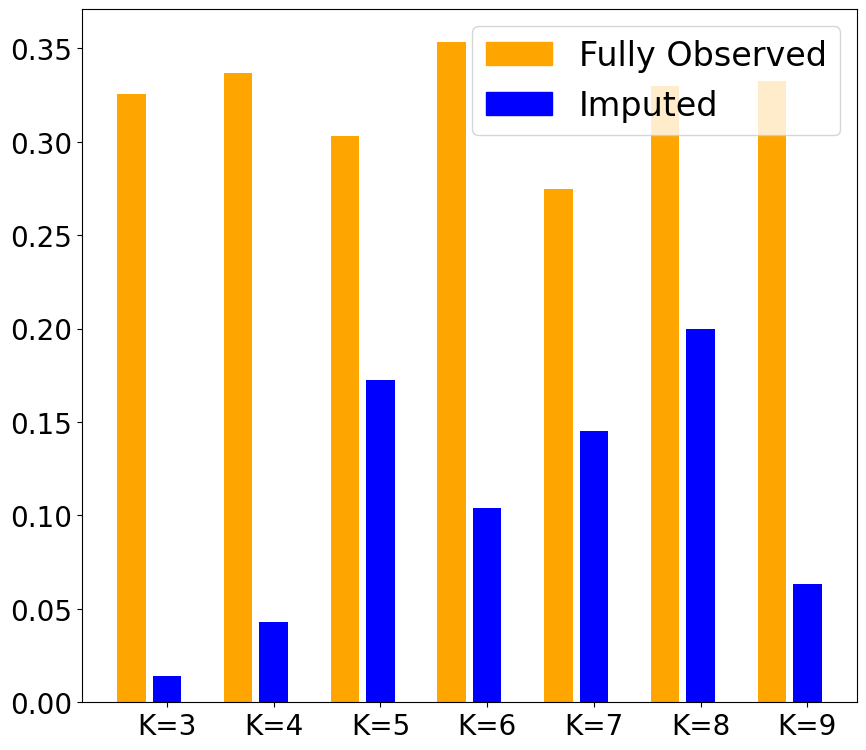

CPU times: user 41min 45s, sys: 2min 50s, total: 44min 35s
Wall time: 13min 24s


In [3]:
%%time 

plot = section_6.IPCASharpeDiff()
char_map = {x[0]:x[1] for x in char_groupings}
sharpes = []
plot.setup(percentile_rank_chars, chars, return_panel, char_groupings,
        regular_chars, dates, permnos, np.array(rts), char_map, monthly_updates)

## Figure 15: Univariate Sorts with and without Missing Values

This figure shows the Sharpe ratio, average return, standard deviation and percentage of stocks for the univariate first and tenth value-weighted characteristic-sorted deciles for different subset of stock with and without imputation. We sequentially restrict the set of stocks to those for which multiple characteristics available. First, we include all stocks for which only the sorting characteristic is available, then in addition we require in addition the availability of size (ME). In the next step, the sorting characteristics, size, and investment (INV) need to be observed. We continue with operating profitability (OP), Net Share Issues (NI), Selling, general and administrative expenses to sales (SGA2S, momentum (R12_2) and long-term reversal (R60_13). We sort based on book-to-market, size, investment and operating profitability. We impute missing values with our baseline local BW-XS model.

CPU times: user 1min 13s, sys: 23.4 s, total: 1min 36s
Wall time: 2min 32s

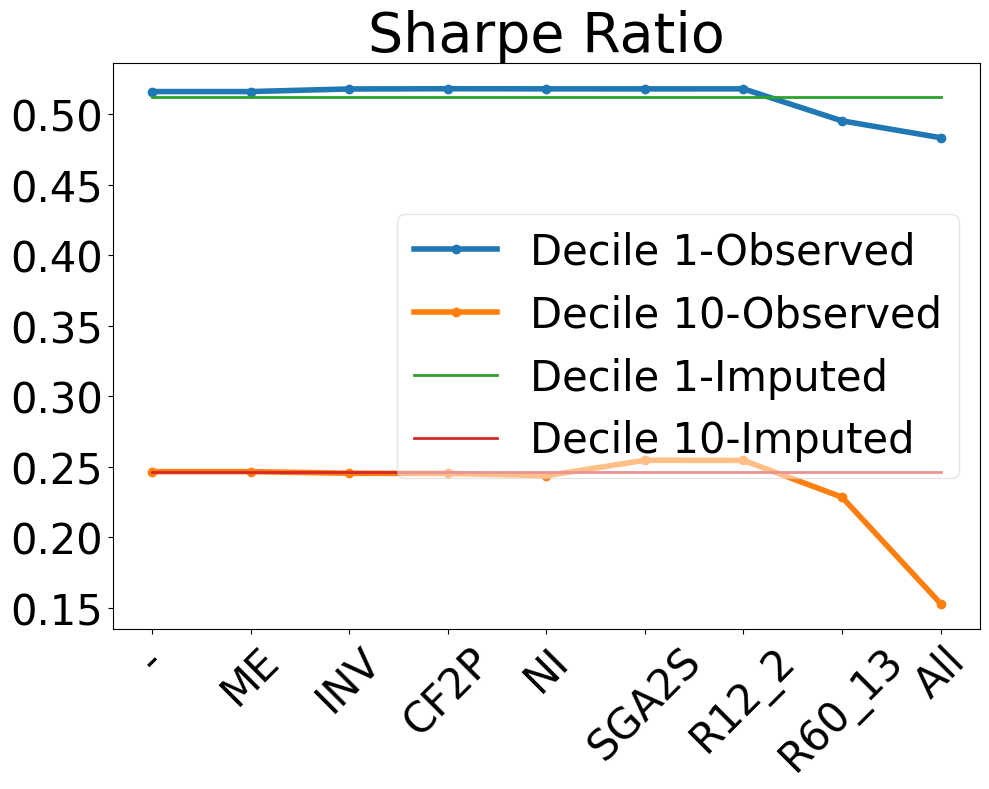

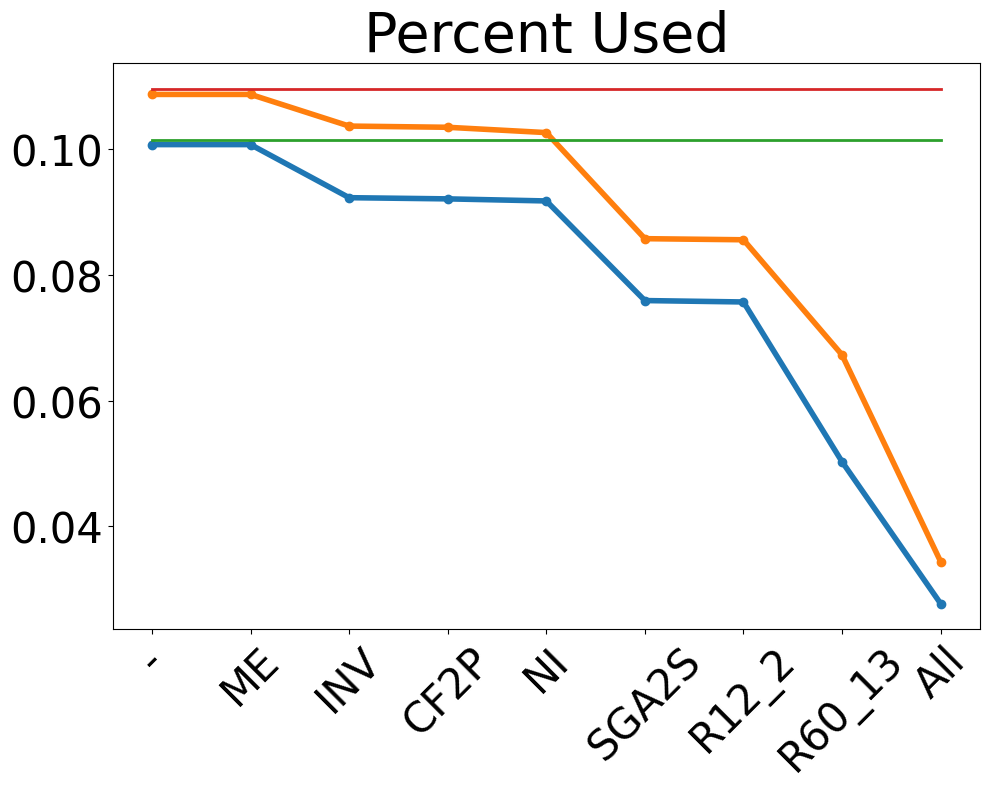

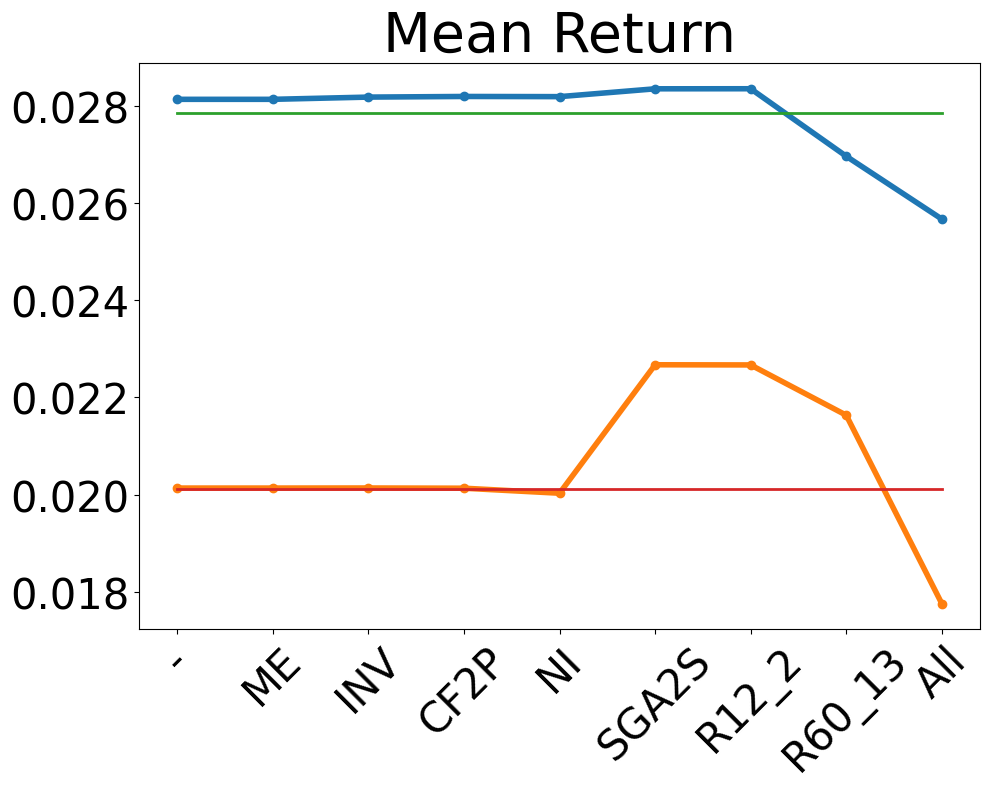

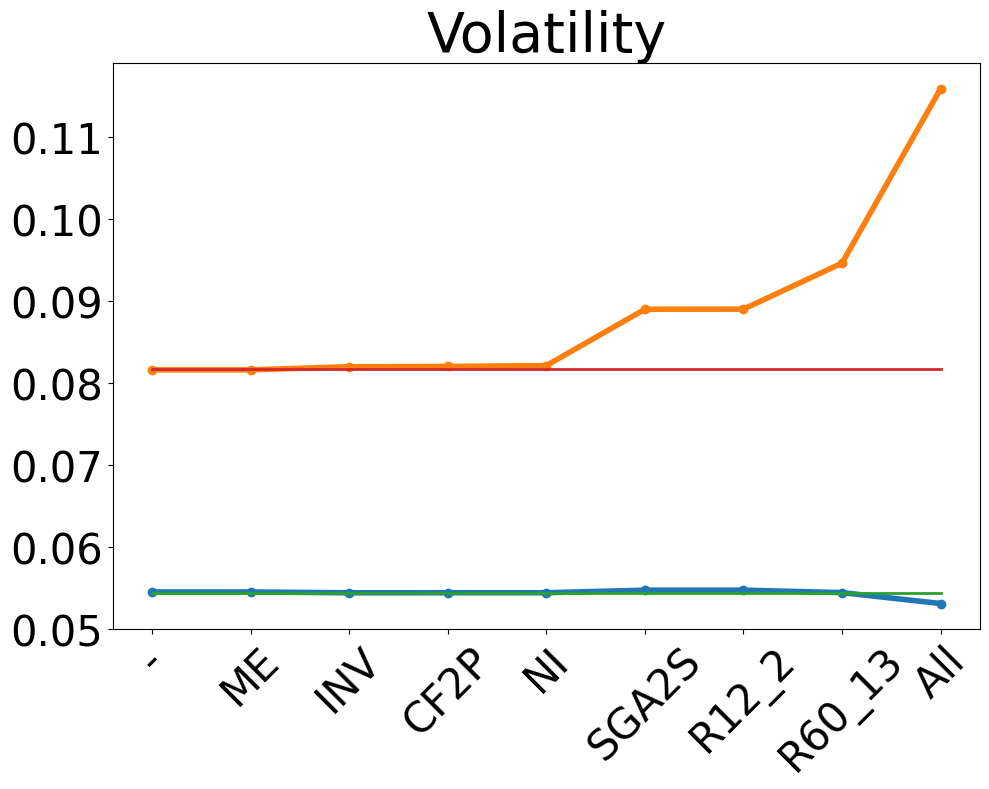

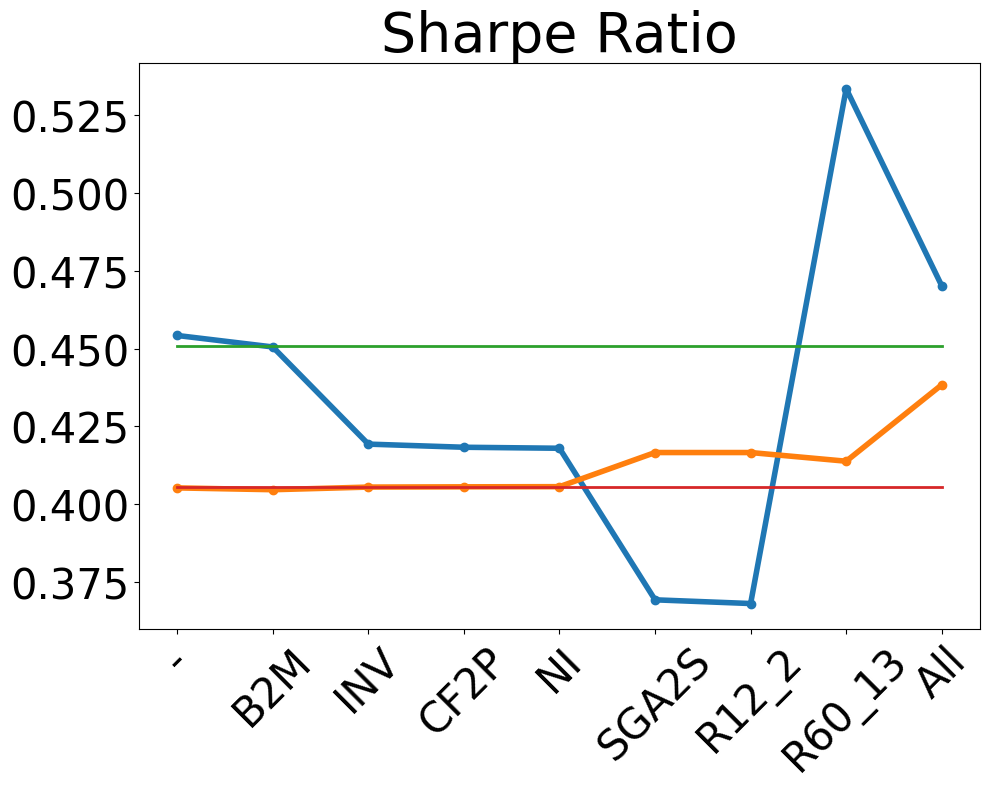

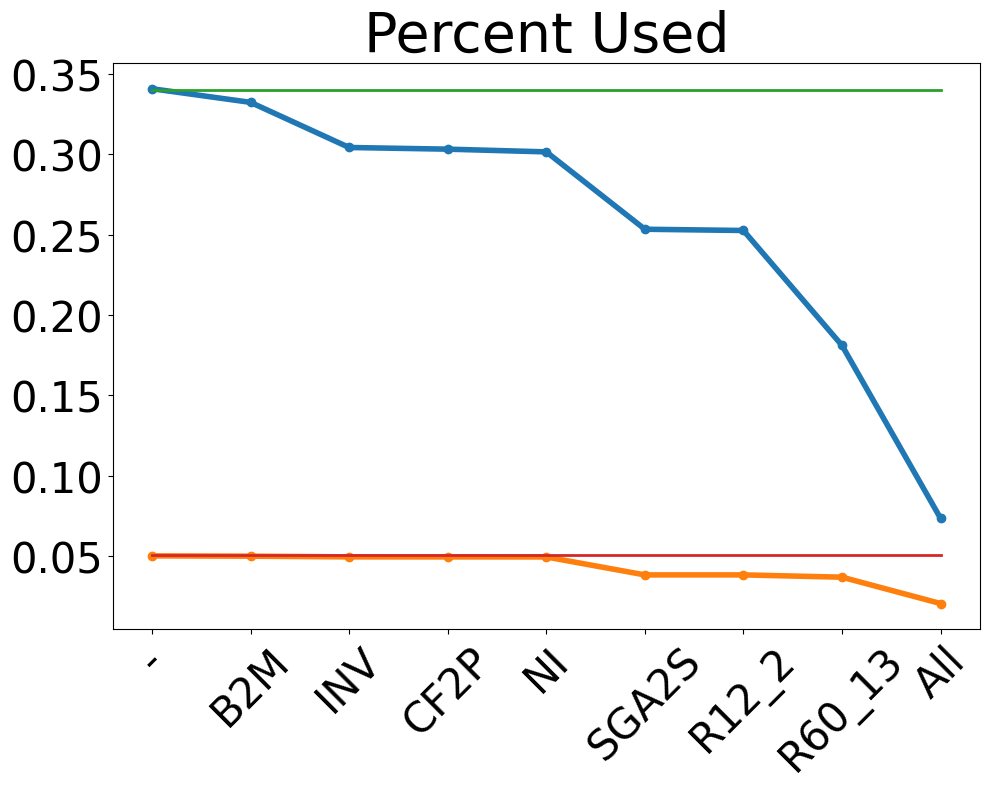

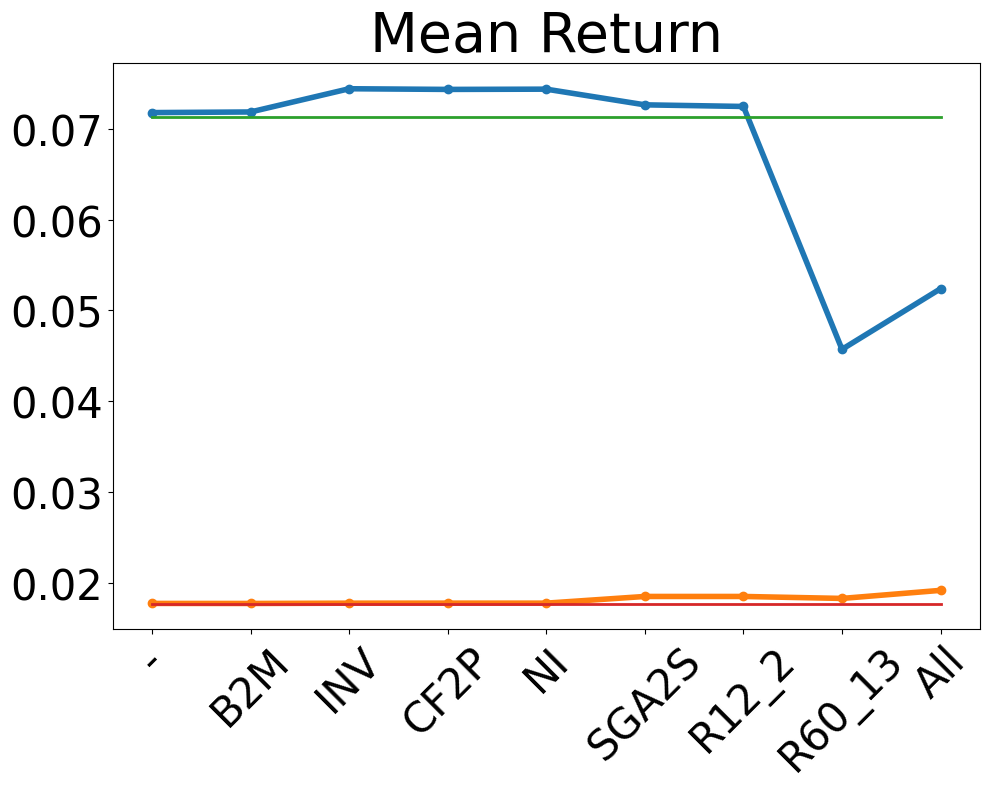

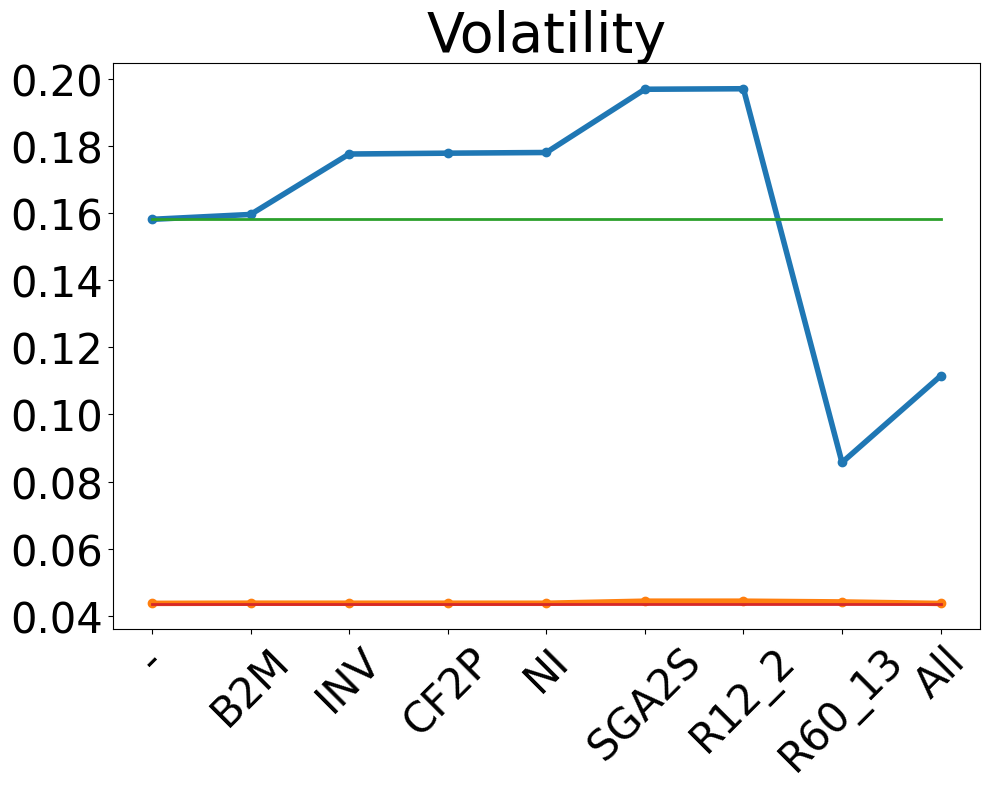

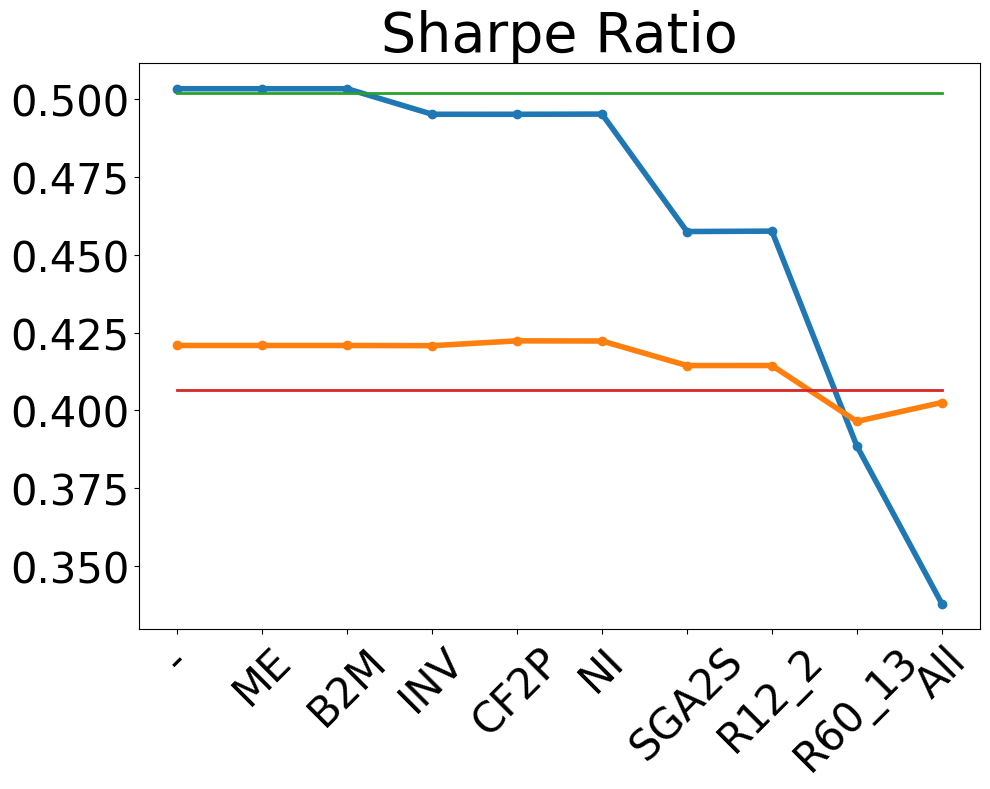

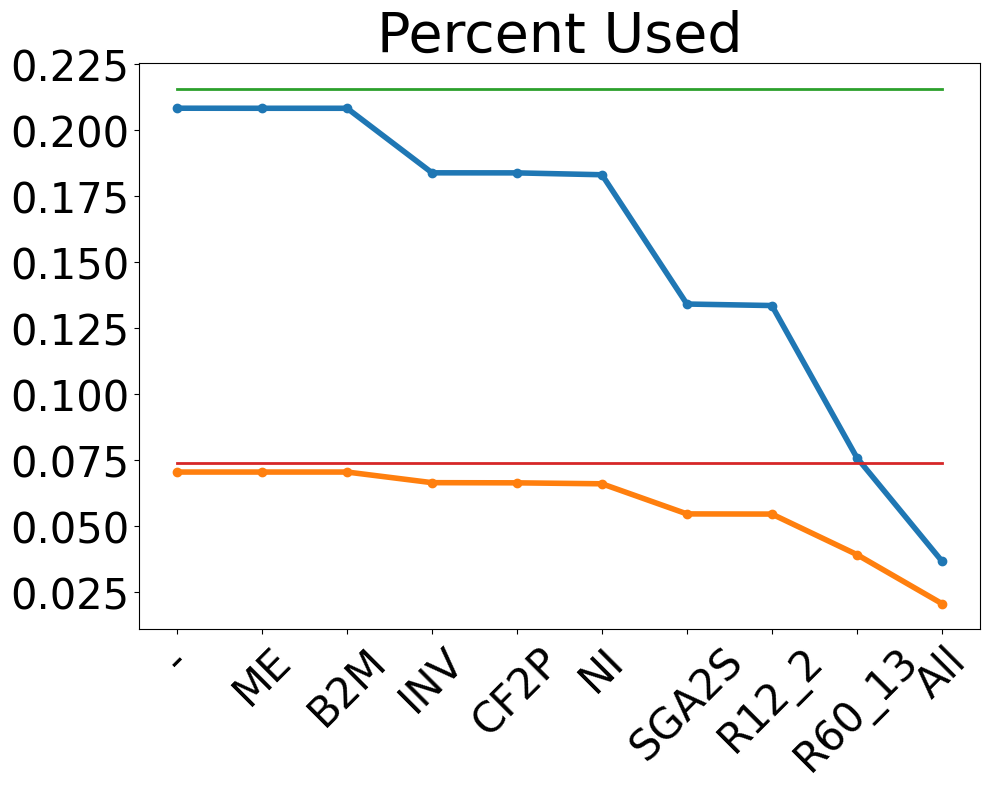

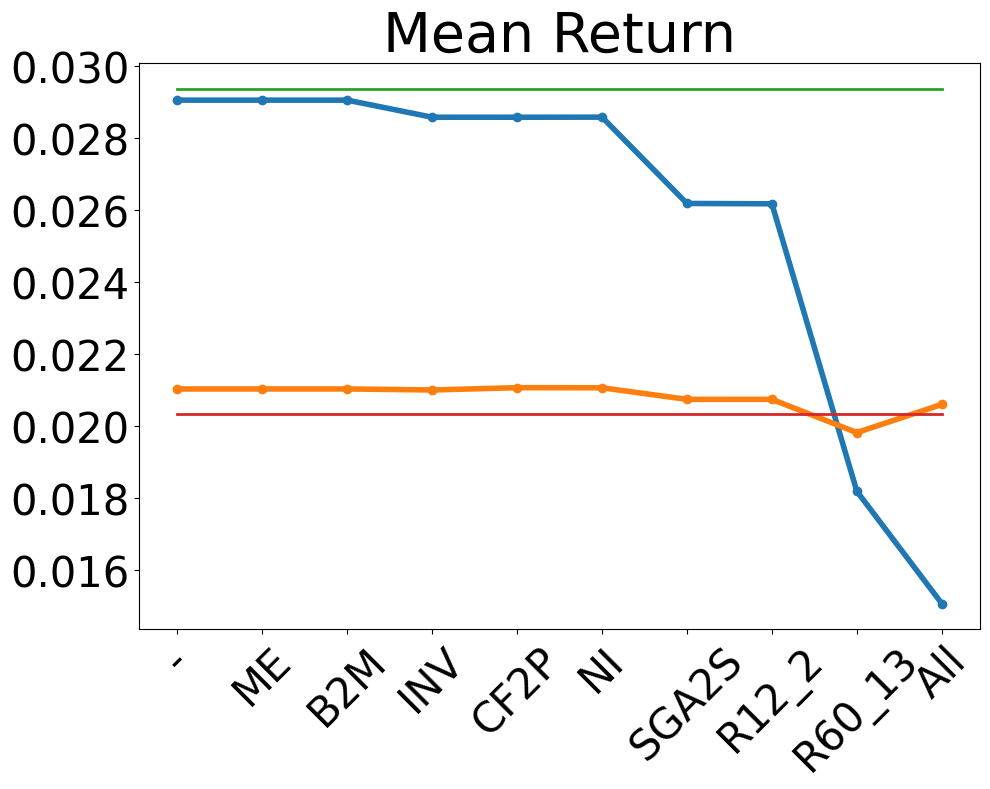

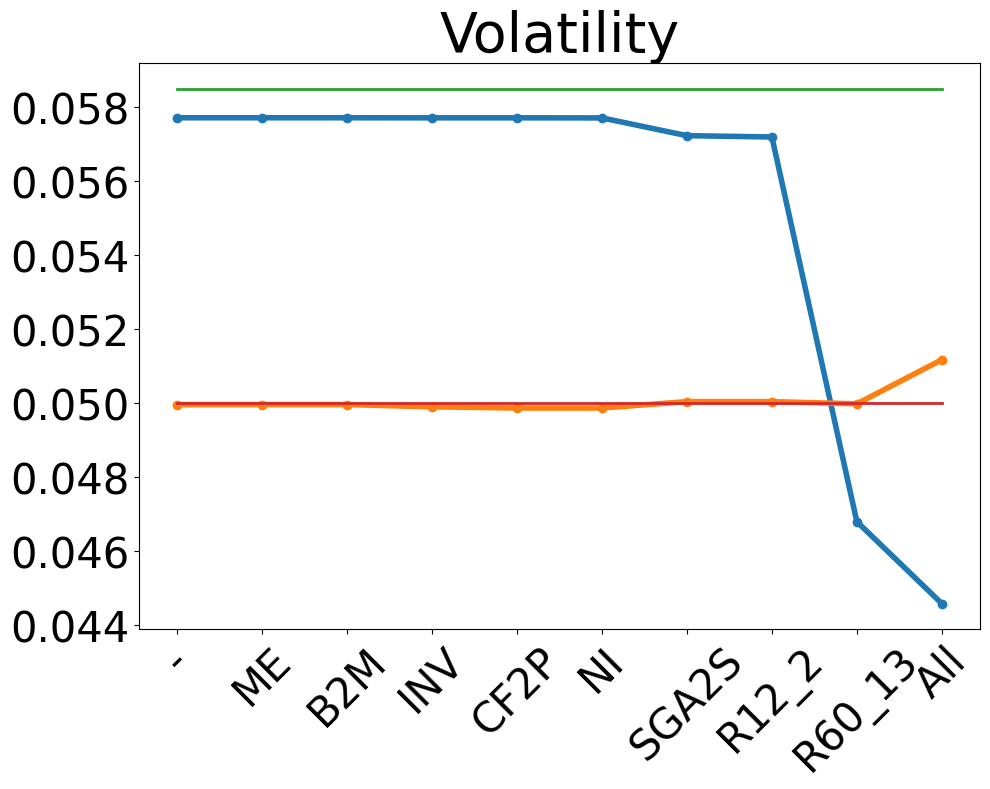

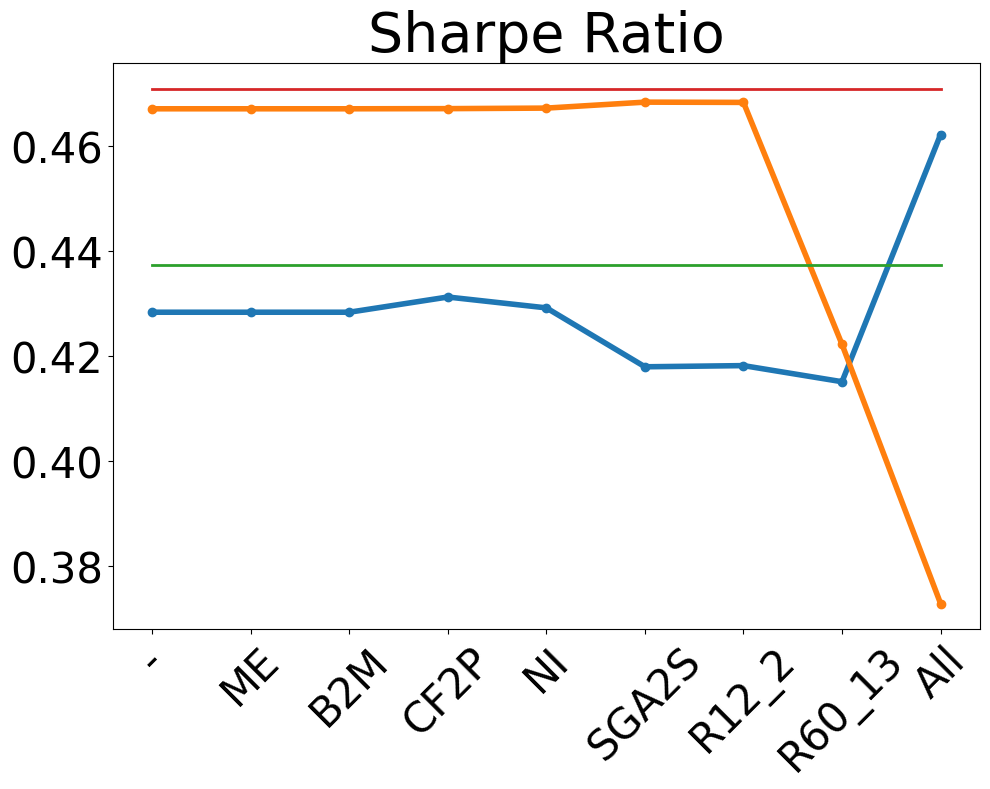

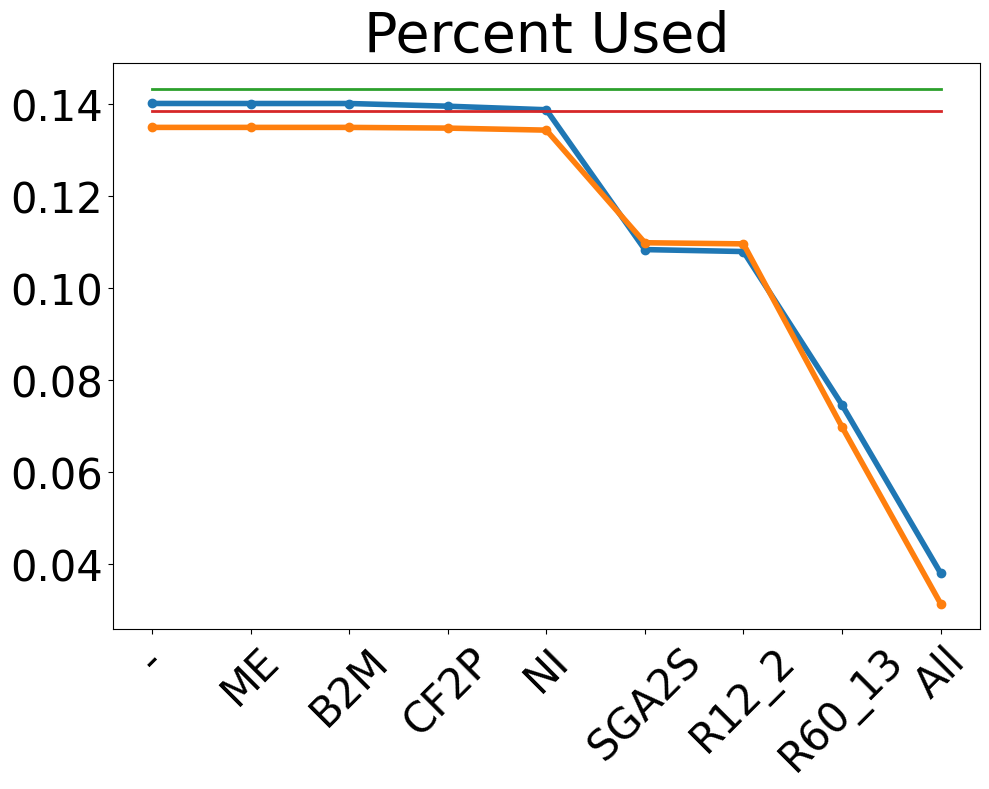

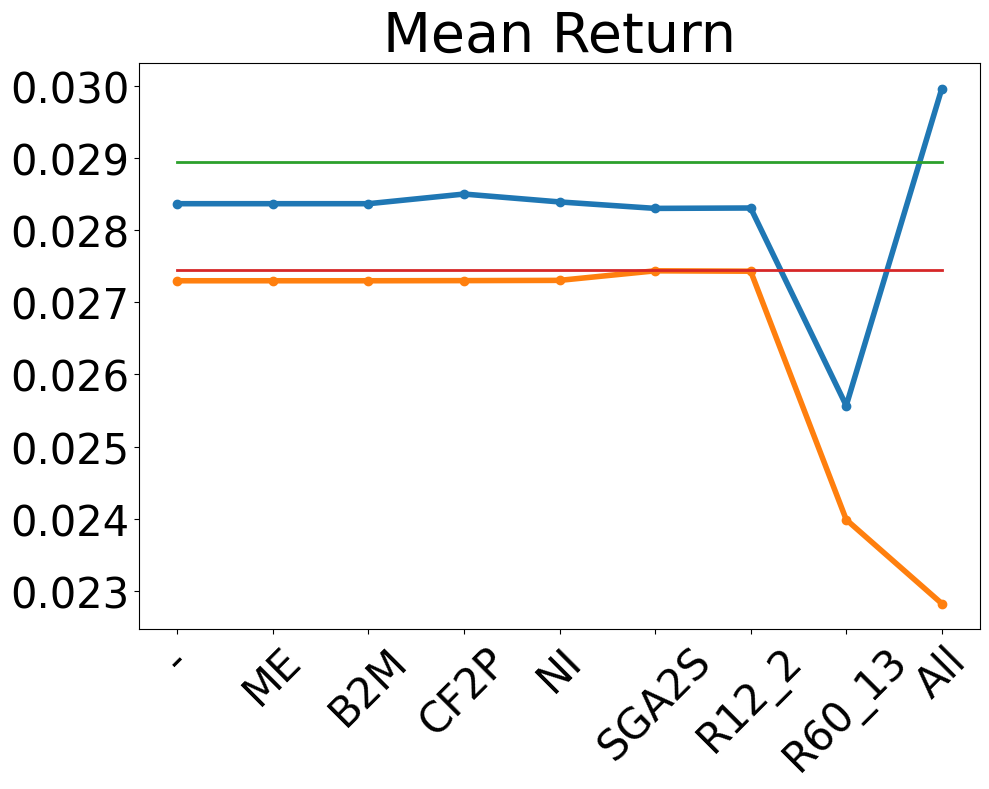

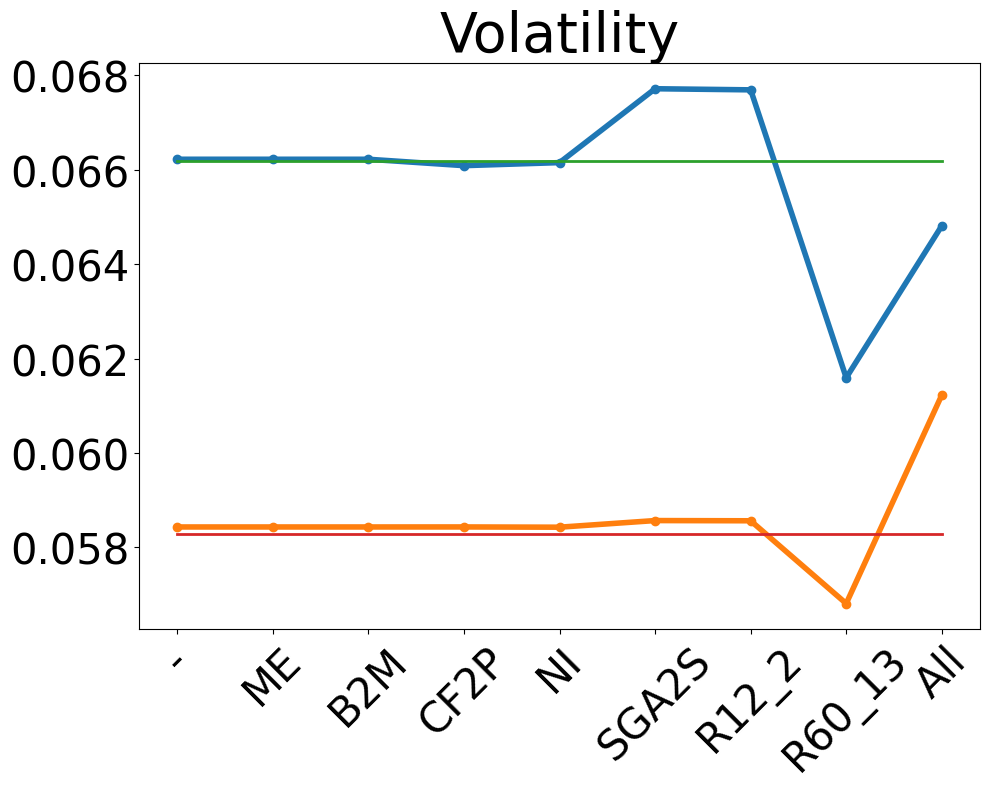

CPU times: user 22.3 s, sys: 1.57 s, total: 23.9 s
Wall time: 24.3 s


In [4]:
%%time 

size_ind = np.argwhere(chars == 'ME')[0][0]
plot = section_6.UnivariateSort()
plot.setup(percentile_rank_chars, return_panel, char_groupings, chars,
        regular_chars, permnos, size_ind, dates)
plot.run()

## Figure 16: Imputation Bias in Pure-Play Mimicking Portfolios and Figure 17: Characteristic Mimicking Factor Portfolios

This figure presents properties of the pure-play mimicking portfolios constructed with imputed characteristics values. Factor portfolios are built via cross-sectional regressions of stock excess returns on characteristics. Some of the characteristic values are masked based on the empirical pattern with the logistic
regression propensity, and imputed via the local B-XS or median value. Panel (a) displays the absolute error in monthly portfolio risk premia based on imputed data relative to true observed values, measured on
the full sample. Panel (b) displays correlations between the time-series of the factor-mimicking portfolios
without masking and those with imputed values.

This figure shows the time-series of cumulative excess returns of characteristic-mimicking factor portfolios
with and without imputation. We estimate characteristic-mimicking factor portfolios with cross-sectional
regressions of stock excess returns on characteristics. We mask the characteristic values based on the
empirical pattern with the logistic regression propensity. The masked values are imputed either with the
local B-XS or median value. The mimicking portfolio without masking is the reference.

CPU times: user 27.6 s, sys: 16.9 s, total: 44.5 s
Wall time: 1min 4s

9767 9767
9767 9767
9767 9767


<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

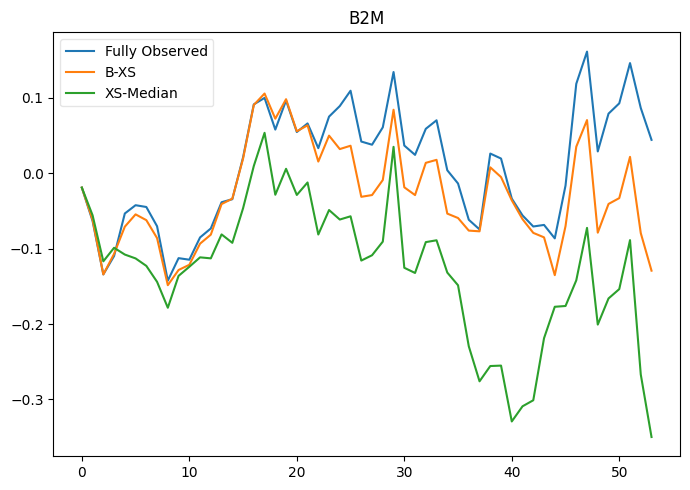

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

...

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

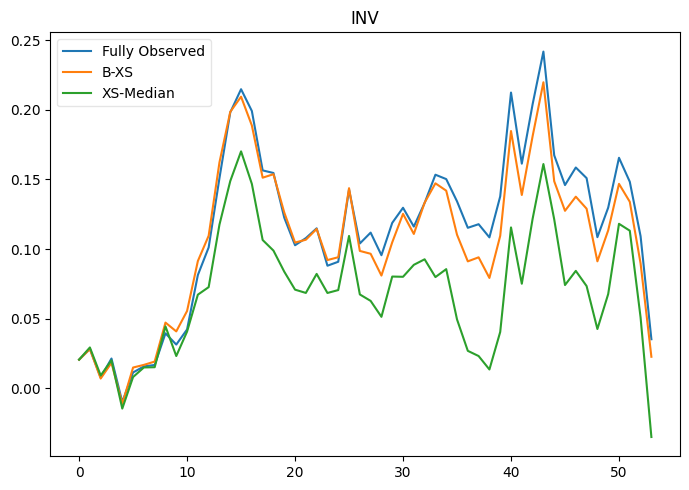

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

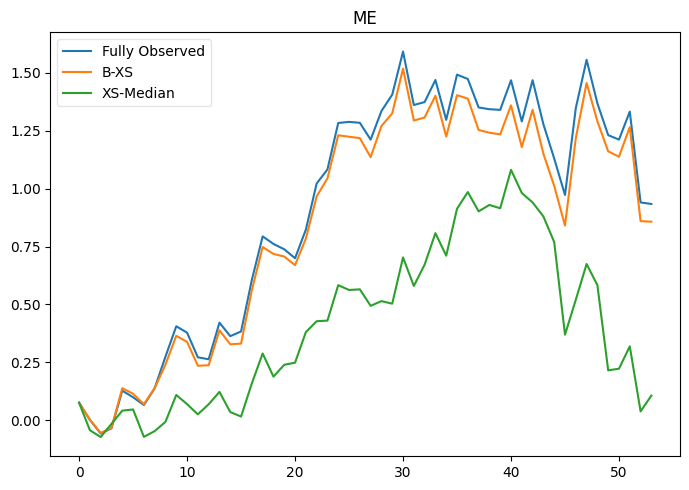

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

...

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

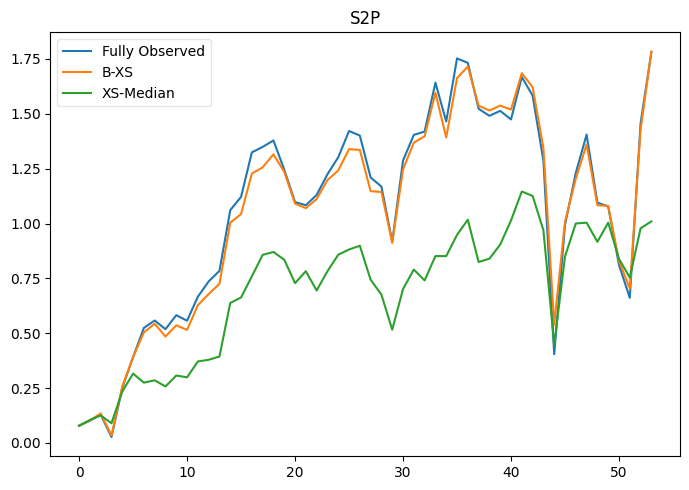

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

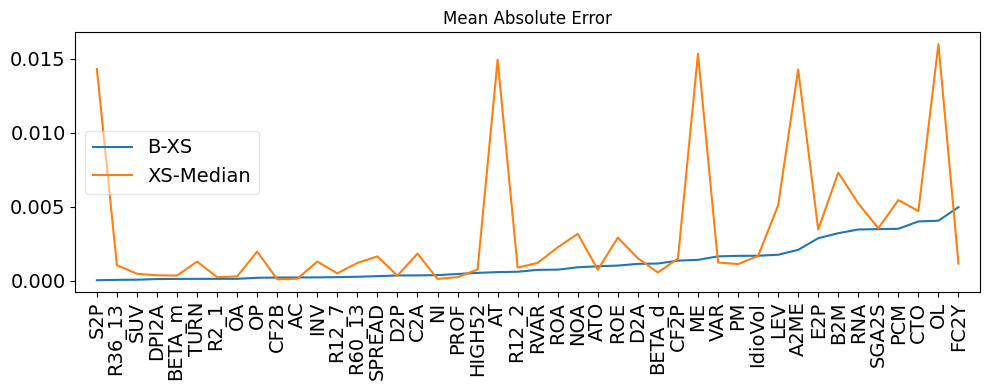

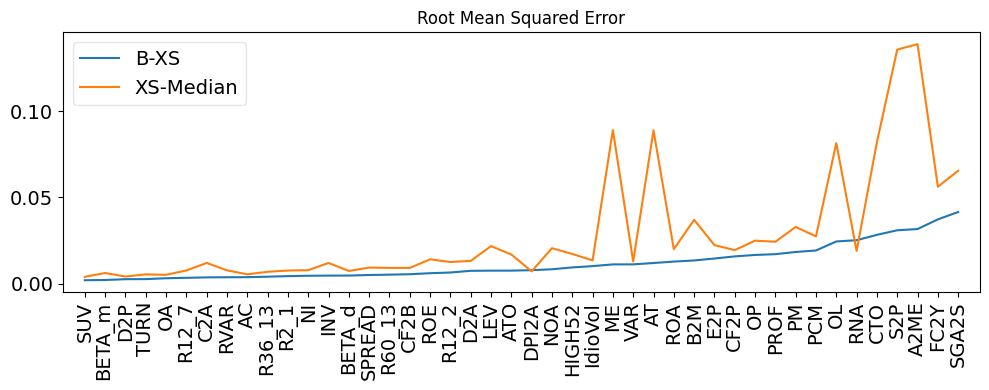

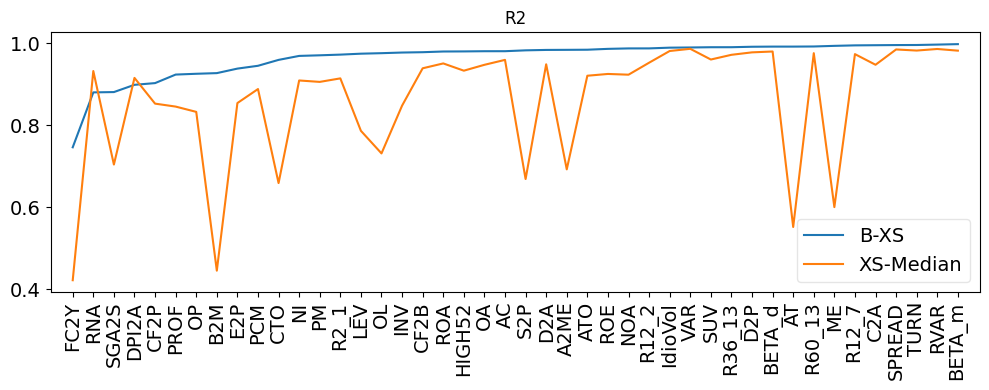

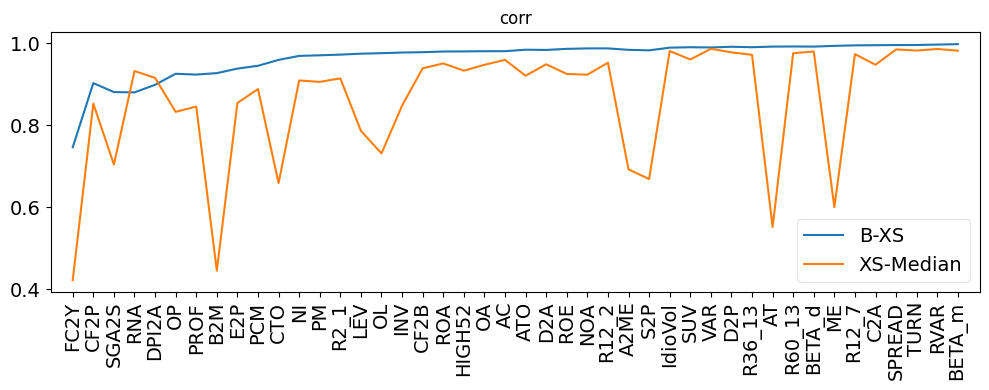

CPU times: user 6.47 s, sys: 1.33 s, total: 7.8 s
Wall time: 8.18 s


In [5]:
%%time 

plot = section_6.PurePlayRegressionsMasked()
plot.setup(percentile_rank_chars, chars, return_panel, char_groupings,
        regular_chars, dates, permnos, rts, char_map, monthly_updates)
plot.run()